In [68]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from src.metapopulation import Metapopulation
from src.delays import heterogeneous_delay_matrix
from src.delays import uniform_delay_matrix, distance_delay_matrix, heterogeneous_delay_matrix

CONFIG = os.path.join(os.path.dirname(os.path.abspath("__file__")), "distance_delays.yaml")
TOPOLOGIES = ['line', 'full', 'ring', 'lattice']
SHAPE_PARAMS = [2.5, 10]  # low p = high heterogeneity, high p = low heterogeneity

In [69]:
def run(topology, p):
    model = Metapopulation()
    model.load_config(CONFIG)
    model.create_network(params={'topology': topology})
    model.create_delay_matrix(mode='heterogeneous', vm=6.0, p=p, target_mean_rho=10.0, seed=42)
    model.initialise_model()
    model.run_simulation()
    return model

In [70]:
def synchrony_index(trajectories):
    E = trajectories[0]  # (N, T)
    return float(np.mean(np.var(E, axis=0)))


def dominant_frequency(trajectories, dt):
    E = trajectories[0]  # (N, T)
    freqs = np.fft.rfftfreq(E.shape[1], d=dt)
    fft_power = np.abs(np.fft.rfft(E, axis=1))
    fft_power[:, 0] = 0
    fft_mean = np.mean(fft_power, axis=0)
    return float(freqs[np.argmax(fft_mean)])


def mean_delay(delay_matrix):
    N = delay_matrix.shape[0]
    mask = ~np.eye(N, dtype=bool)
    return float(np.mean(delay_matrix[mask]))

In [71]:
results = {}
for topology in TOPOLOGIES:
    for p in SHAPE_PARAMS:
        print(f"Running {topology}, p={p}...")
        m = run(topology, p)
        D = m.model.params['rho']
        results[(topology, p)] = {
            'time': m.model.time_array,
            'trajectories': m.model.trajectories,
            'mean_delay': mean_delay(D),
            'synchrony': synchrony_index(m.model.trajectories[:, :, m.model.time_array >= 20]),
            'dom_freq': dominant_frequency(m.model.trajectories[:, :, m.model.time_array >= 20], m.model.dt)
        }
print("All runs complete.")

Running line, p=2.5...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  0.98799381,  1.50739926,  3.32377391,  4.88337154,
         3.49984451,  6.92638566,  6.24710798,  7.59083795,  6.30310363,
        13.72178156,  6.3777156 , 19.67012453, 11.15191608, 12.92426837,
        26.20763844],
       [ 0.98799381,  0.        ,  0.8157546 ,  2.61086381,  6.73093421,
         3.02743311, 15.21238882, 11.82153281,  7.81287187,  5.62510975,
         7.0730669 ,  9.97852397, 44.13917313, 20.30568646, 19.03071831,
        32.5214588 ],
       [ 1.50739926,  0.8157546 ,  0.        ,  5.09121179,  2.1655464 ,
         2.31339211,  6.17920845,  3.54266646, 20.13849021, 17.02038417,
         8.7785877 , 14.74066647,  8.11098067,  9.88190464, 18.73494073,
        40.46731365],
       [ 3.32377391,  2.61086381,  5.09121179,  0.        ,  1.69089271,
         1.77045154,  2.37657061,  6.53196065, 25.5812231

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Running line, p=10...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.50534914,  2.62862445, 10.05535613,  6.36568019,
         8.33373631,  7.59075601, 11.36129673, 11.45225937, 13.28149328,
        12.65478459, 19.36399956, 13.74780498, 24.81486379, 19.64889588,
        21.83730882],
       [ 1.50534914,  0.        ,  0.89170249,  3.92773846,  4.10508003,
         6.88011042, 10.94129646,  7.90279247, 17.35548198, 16.55978773,
        14.37359124, 12.68093972, 14.76973668, 18.15223111, 35.87417015,
        27.1060868 ],
       [ 2.62862445,  0.89170249,  0.        ,  1.81356007,  4.44099416,
         9.0338335 ,  6.2956834 ,  6.64889522, 11.15108714,  8.91187736,
        20.61712351, 20.36926755, 15.84078081, 20.98958369, 16.37279777,
        18.67123902],
       [10.05535613,  3.92773846,  1.81356007,  0.        ,  1.86744085,
         5.0039314 ,

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Running full, p=2.5...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  5.40254285,  4.12137659,  6.05834803,  6.67580704,
         3.82756649,  6.31247131,  4.88005786,  5.18852283,  3.82962224,
         7.50333782,  3.17041754,  8.96333982,  4.6908348 ,  5.04803004,
         9.55389861],
       [ 5.40254285,  0.        ,  4.46070527,  7.13835629, 12.26868707,
         4.13864869, 16.6368619 , 10.77374123,  6.10318677,  3.84489967,
         4.29743439,  5.45645155, 21.94196442,  9.25295454,  8.00489846,
        12.70240575],
       [ 4.12137659,  4.46070527,  0.        , 27.8397392 ,  5.92081506,
         4.21669311,  8.44727929,  3.87439825, 18.35353213, 13.29582582,
         6.00037874,  8.95609329,  4.43524245,  4.9123802 ,  8.53719253,
        17.0217819 ],
       [ 6.05834803,  7.13835629, 27.8397392 ,  0.        ,  9.24613119,
         4.84058719

...

Using default integration parameters.
Running lattice, p=2.5...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  2.02436337,  3.08860624,  6.81029182,  2.50146266,
         2.86842163,  7.09595612,  7.31434114,  3.8883377 ,  4.30494334,
        11.24617249,  5.93986693, 10.07584239,  7.03072933,  9.45762704,
        21.47939909],
       [ 2.02436337,  0.        ,  1.6714515 ,  5.34956496,  9.19429288,
         1.55077508, 12.46785251, 12.11094533,  6.86069581,  2.88141131,
         4.83081892,  8.17825304, 32.88711271, 10.40140321, 11.99792292,
        23.79831641],
       [ 3.08860624,  1.6714515 ,  0.        , 10.43170775,  6.65568868,
         3.16003751,  3.16524333,  2.90351788, 27.5086892 , 14.94606341,
         4.49675171, 10.06769644,  8.30955216,  7.36278658,  9.59680299,
        25.51263183],
       [ 6.81029182,  5.34956496, 10.43170775,  0.        , 13.85831062,
         5.44138

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Running lattice, p=10...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  3.22063044,  5.62383017, 21.51300659,  3.40477547,
         7.1318697 ,  8.12004975, 13.88972054,  6.12540541,  9.47172991,
        10.82974927, 18.83111505,  7.35321095, 16.33549084, 15.0135631 ,
        18.68799722],
       [ 3.22063044,  0.        ,  1.90775953,  8.40322931,  5.85509604,
         3.67992587,  9.36337529,  8.45384411, 15.91342081,  8.85724031,
        10.25056229, 10.85213238, 11.49062661,  9.70898152, 23.61577249,
        20.71154262],
       [ 5.62383017,  1.90775953,  0.        ,  3.8800346 , 14.25197707,
        12.8850016 ,  3.36733669,  5.69001136, 15.90485097,  8.17139246,
        11.02736462, 14.52639374, 16.94533826, 16.32957135,  8.75722604,
        12.29117582],
       [21.51300659,  8.40322931,  3.8800346 ,  0.        , 15.98124093,
        16.058547

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
All runs complete.


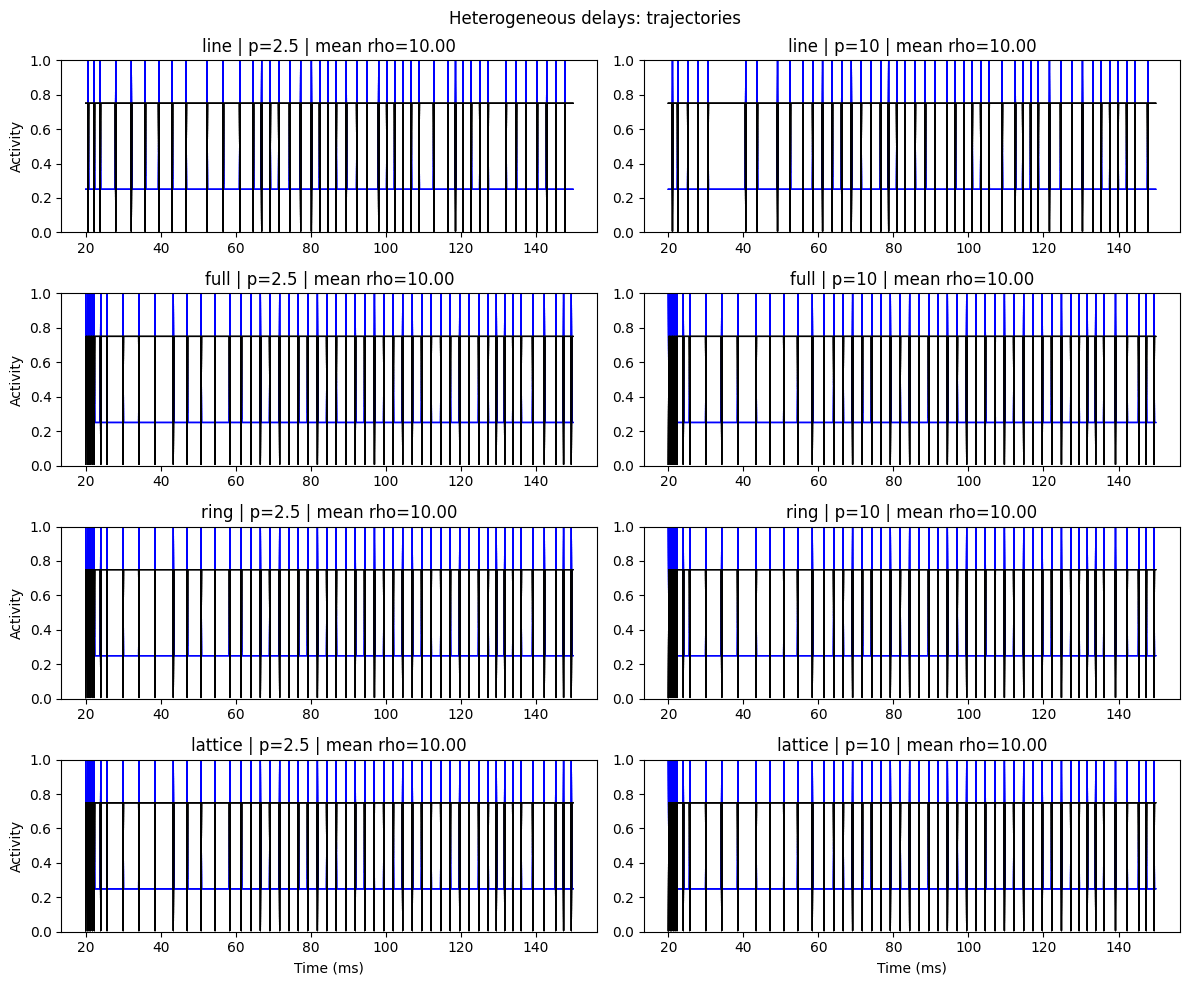

In [72]:
fig, axes = plt.subplots(len(TOPOLOGIES), len(SHAPE_PARAMS), figsize=(12, 10))
fig.suptitle("Heterogeneous delays: trajectories")

for i, topology in enumerate(TOPOLOGIES):
    for j, p in enumerate(SHAPE_PARAMS):
        r = results[(topology, p)]
        ax = axes[i, j]
        t = r['time']
        mask = t >= 20
        ax.plot(t[mask], r['trajectories'][0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
        ax.plot(t[mask], r['trajectories'][1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
        ax.set_title(f"{topology} | p={p} | mean rho={r['mean_delay']:.2f}")
        ax.set_ylim(0, 1)
        if i == len(TOPOLOGIES) - 1:
            ax.set_xlabel("Time (ms)")
        if j == 0:
            ax.set_ylabel("Activity")

plt.tight_layout()
plt.savefig("kavya_figures/heterogeneous_delays_trajectories.png", dpi=150)
plt.show()

sparse networks (path/line graph) produce irregular, asynchronous dynamics while dense networks (complete graph) maintain stable synchronised limit cycles

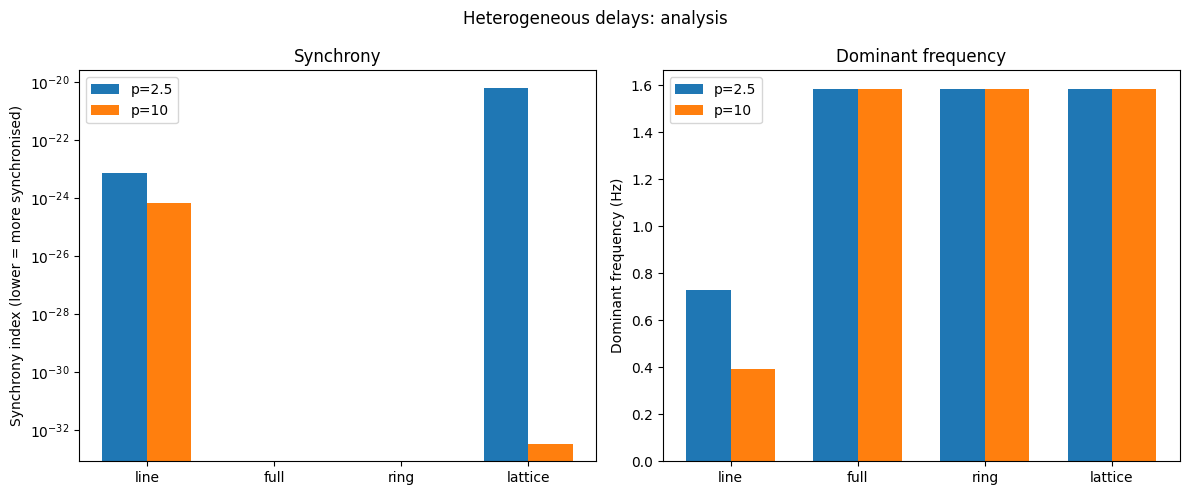

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Heterogeneous delays: analysis")

x = np.arange(len(TOPOLOGIES))
width = 0.35

for k, p in enumerate(SHAPE_PARAMS):
    sync = [results[(t, p)]['synchrony'] for t in TOPOLOGIES]
    freq = [results[(t, p)]['dom_freq'] for t in TOPOLOGIES]
    axes[0].bar(x + k*width, sync, width, label=f"p={p}")
    axes[1].bar(x + k*width, freq, width, label=f"p={p}")

axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(TOPOLOGIES)
axes[0].set_ylabel("Synchrony index (lower = more synchronised)")
axes[0].set_title("Synchrony")
axes[0].set_yscale('log')
axes[0].legend()

axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(TOPOLOGIES)
axes[1].set_ylabel("Dominant frequency (Hz)")
axes[1].set_title("Dominant frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("kavya_figures/heterogeneous_delays_analysis.png", dpi=150)
plt.show()

In [74]:
print(f"{'Topology':<10} {'p':<6} {'Mean delay':<12} {'Synchrony':<15} {'Dom freq (Hz)':<10}")
print("-" * 55)
for topology in TOPOLOGIES:
    for p in SHAPE_PARAMS:
        r = results[(topology, p)]
        print(f"{topology:<10} {p:<6} {r['mean_delay']:<12.3f} {r['synchrony']:<15.3e} {r['dom_freq']:<10.3f}")

Topology   p      Mean delay   Synchrony       Dom freq (Hz)
-------------------------------------------------------
line       2.5    10.000       7.088e-24       0.731     
line       10     10.000       6.582e-25       0.392     
full       2.5    10.000       0.000e+00       1.585     
full       10     10.000       0.000e+00       1.585     
ring       2.5    10.000       0.000e+00       1.585     
ring       10     10.000       0.000e+00       1.585     
lattice    2.5    10.000       6.162e-21       1.585     
lattice    10     10.000       3.451e-33       1.585     


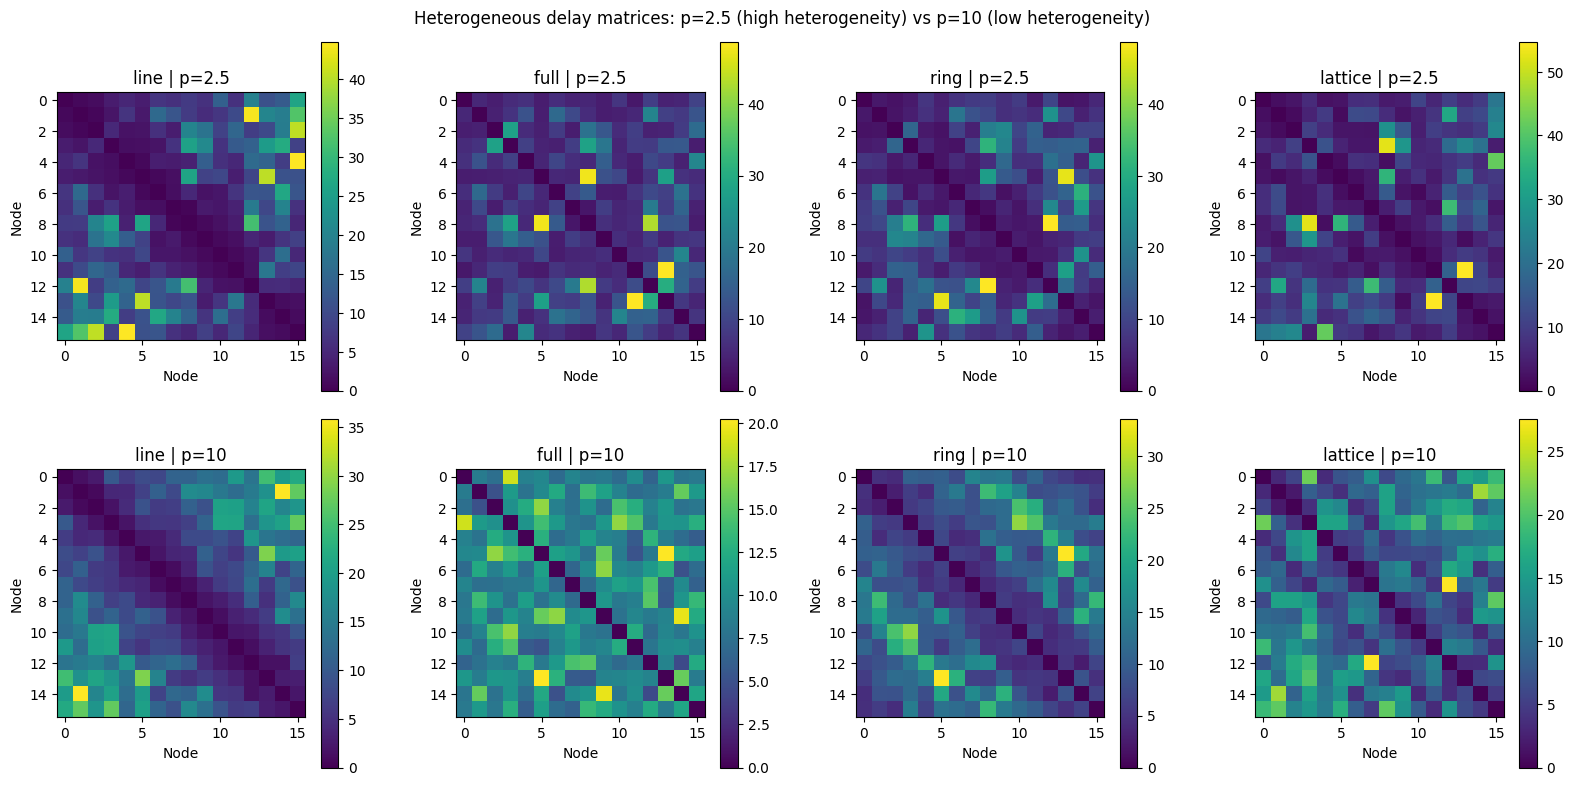

In [75]:
fig, axes = plt.subplots(2, len(TOPOLOGIES), figsize=(16, 8))
fig.suptitle("Heterogeneous delay matrices: p=2.5 (high heterogeneity) vs p=10 (low heterogeneity)")

for i, topology in enumerate(TOPOLOGIES):
    m_temp = Metapopulation()
    m_temp.load_config(CONFIG)
    m_temp.create_network(params={'topology': topology})
    
    D_low_p = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=2.5, target_mean_rho=10.0, seed=42)
    D_high_p = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=10, target_mean_rho=10.0, seed=42)
    
    im0 = axes[0, i].imshow(D_low_p, cmap='viridis')
    axes[0, i].set_title(f"{topology} | p=2.5")
    axes[0, i].set_xlabel("Node")
    axes[0, i].set_ylabel("Node")
    plt.colorbar(im0, ax=axes[0, i])
    
    im1 = axes[1, i].imshow(D_high_p, cmap='viridis')
    axes[1, i].set_title(f"{topology} | p=10")
    axes[1, i].set_xlabel("Node")
    axes[1, i].set_ylabel("Node")
    plt.colorbar(im1, ax=axes[1, i])

plt.tight_layout()
plt.savefig("kavya_figures/heterogeneous_delay_matrices.png", dpi=150)
plt.show()

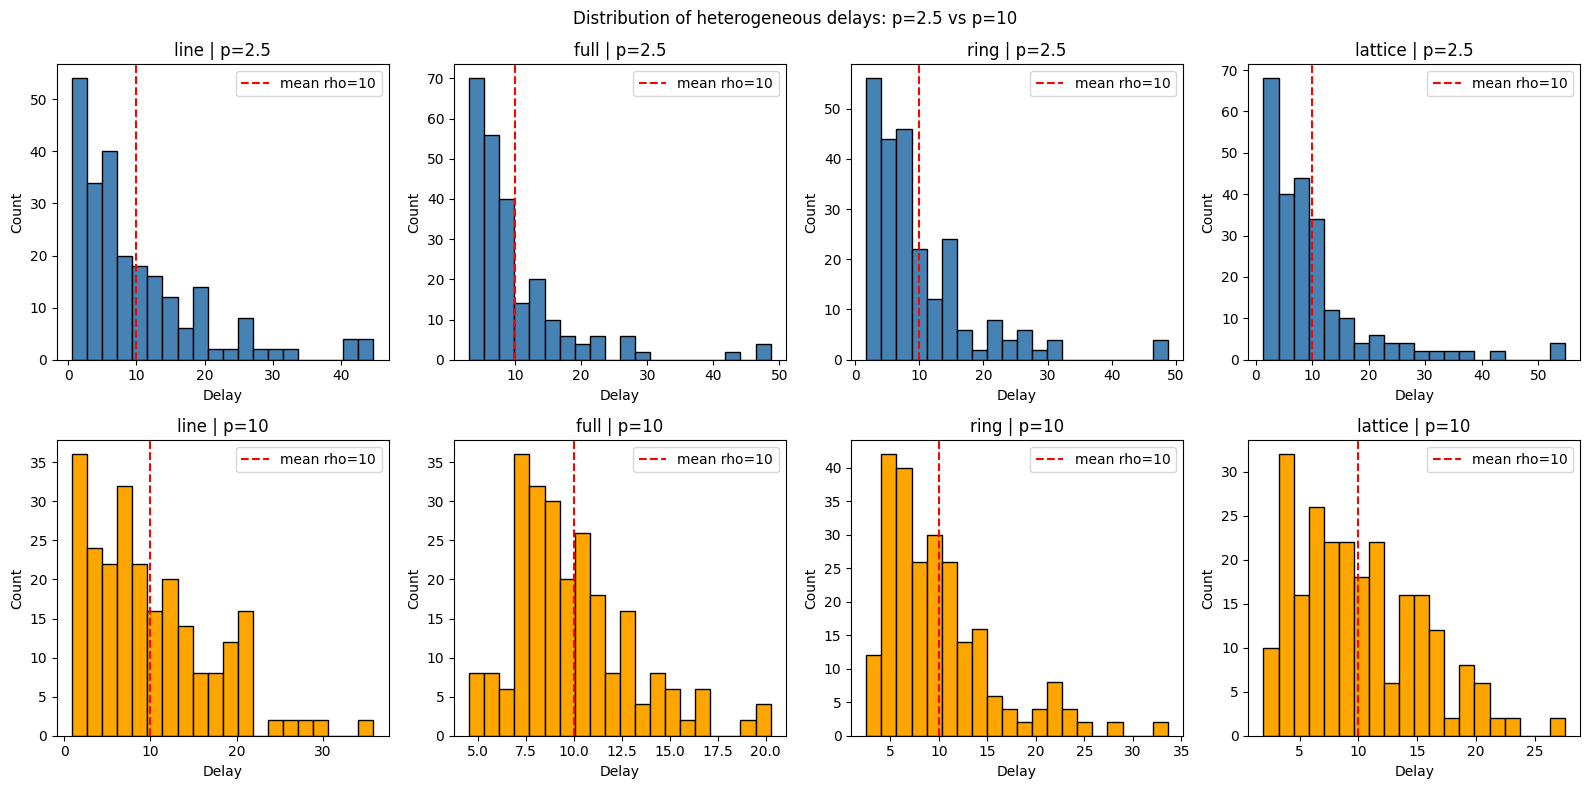

In [76]:
fig, axes = plt.subplots(2, len(TOPOLOGIES), figsize=(16, 8))
fig.suptitle("Distribution of heterogeneous delays: p=2.5 vs p=10")

for i, topology in enumerate(TOPOLOGIES):
    m_temp = Metapopulation()
    m_temp.load_config(CONFIG)
    m_temp.create_network(params={'topology': topology})
    
    D_low_p = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=2.5, target_mean_rho=10.0, seed=42)
    D_high_p = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=10, target_mean_rho=10.0, seed=42)
    
    N = m_temp.network.N
    mask = ~np.eye(N, dtype=bool)
    
    axes[0, i].hist(D_low_p[mask].flatten(), bins=20, color='steelblue', edgecolor='black')
    axes[0, i].axvline(x=10, color='red', linestyle='--', label='mean rho=10')
    axes[0, i].set_title(f"{topology} | p=2.5")
    axes[0, i].set_xlabel("Delay")
    axes[0, i].set_ylabel("Count")
    axes[0, i].legend()
    
    axes[1, i].hist(D_high_p[mask].flatten(), bins=20, color='orange', edgecolor='black')
    axes[1, i].axvline(x=10, color='red', linestyle='--', label='mean rho=10')
    axes[1, i].set_title(f"{topology} | p=10")
    axes[1, i].set_xlabel("Delay")
    axes[1, i].set_ylabel("Count")
    axes[1, i].legend()

plt.tight_layout()
plt.savefig("kavya_figures/heterogeneous_delay_distributions.png", dpi=150)
plt.show()

In [77]:
print(f"{'Topology':<10} {'p':<6} {'Mean delay':<12} {'Synchrony':<15} {'Dom freq (Hz)':<10}")
print("-" * 55)
for topology in TOPOLOGIES:
    for p in SHAPE_PARAMS:
        r = results[(topology, p)]
        print(f"{topology:<10} {p:<6} {r['mean_delay']:<12.3f} {r['synchrony']:<15.3e} {r['dom_freq']:<10.3f}")

Topology   p      Mean delay   Synchrony       Dom freq (Hz)
-------------------------------------------------------
line       2.5    10.000       7.088e-24       0.731     
line       10     10.000       6.582e-25       0.392     
full       2.5    10.000       0.000e+00       1.585     
full       10     10.000       0.000e+00       1.585     
ring       2.5    10.000       0.000e+00       1.585     
ring       10     10.000       0.000e+00       1.585     
lattice    2.5    10.000       6.162e-21       1.585     
lattice    10     10.000       3.451e-33       1.585     


Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10.,
        10., 10., 10.],
   

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.76470588,  3.52941176,  5.29411765,  7.05882353,
         8.82352941, 10.58823529, 12.35294118, 14.11764706, 15.88235294,
        17.64705882, 19.41176471, 21.17647059, 22.94117647, 24.70588235,
        26.47058824],
       [ 1.76470588,  0.        ,  1.76470588,  3.52941176,  5.29411765,
         7.05882353,  8.82352941, 10.58823529, 12.35294118, 14.11764706,
        15.88235294, 17.64705882, 19.41176471, 21.17647059, 22.94117647,
        24.70588235],
       [ 3.52941176,  1.76470588,  0.        ,  1.76470588,  3.52941176,
         5.29411765,  7.05882353,  8.82352941, 10.58823529, 12.35294118,
        14.11764706, 15.88235294, 17.64705882, 19.41176471, 21.17647059,
        22.94117647],
       [ 5.29411765,  3.52941176,  1.76470588,  0.        ,  1.76470588,
         3.52941176,  5.29411765,  7.05882

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  0.98799381,  1.50739926,  3.32377391,  4.88337154,
         3.49984451,  6.92638566,  6.24710798,  7.59083795,  6.30310363,
        13.72178156,  6.3777156 , 19.67012453, 11.15191608, 12.92426837,
        26.20763844],
       [ 0.98799381,  0.        ,  0.8157546 ,  2.61086381,  6.73093421,
         3.02743311, 15.21238882, 11.82153281,  7.81287187,  5.62510975,
         7.0730669 ,  9.97852397, 44.13917313, 20.30568646, 19.03071831,
        32.5214588 ],
       [ 1.50739926,  0.8157546 ,  0.        ,  5.09121179,  2.1655464 ,
         2.31339211,  6.17920845,  3.54266646, 20.13849021, 17.02038417,
         8.7785877 , 14.74066647,  8.11098067,  9.88190464, 18.73494073,
        40.46731365],
       [ 3.32377391,  2.61086381,  5.09121179,  0.        ,  1.69089271,
         1.77045154,  2.37657061,  6.53196

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.


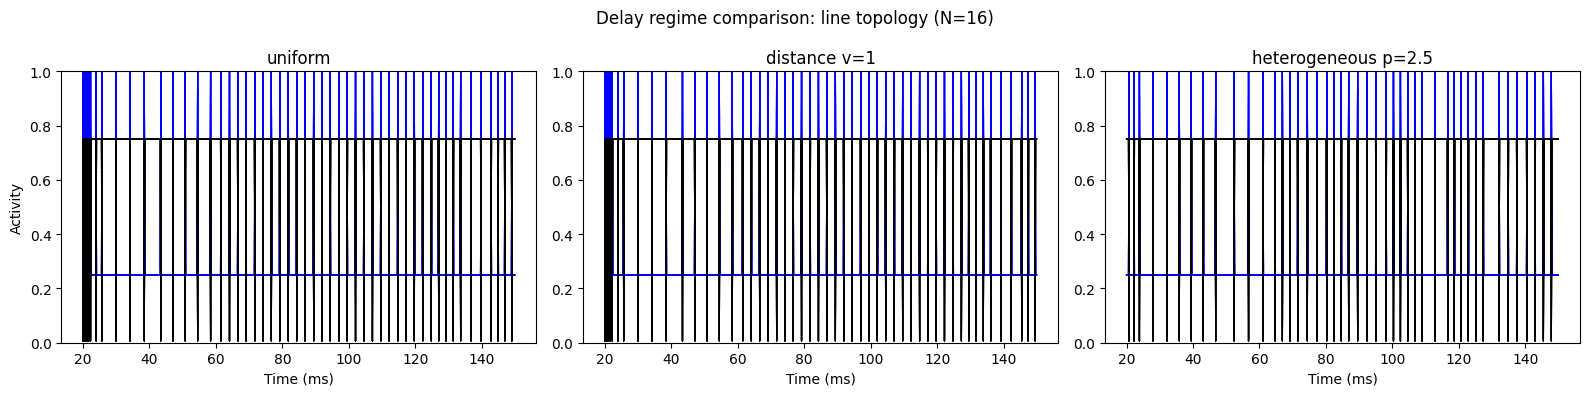

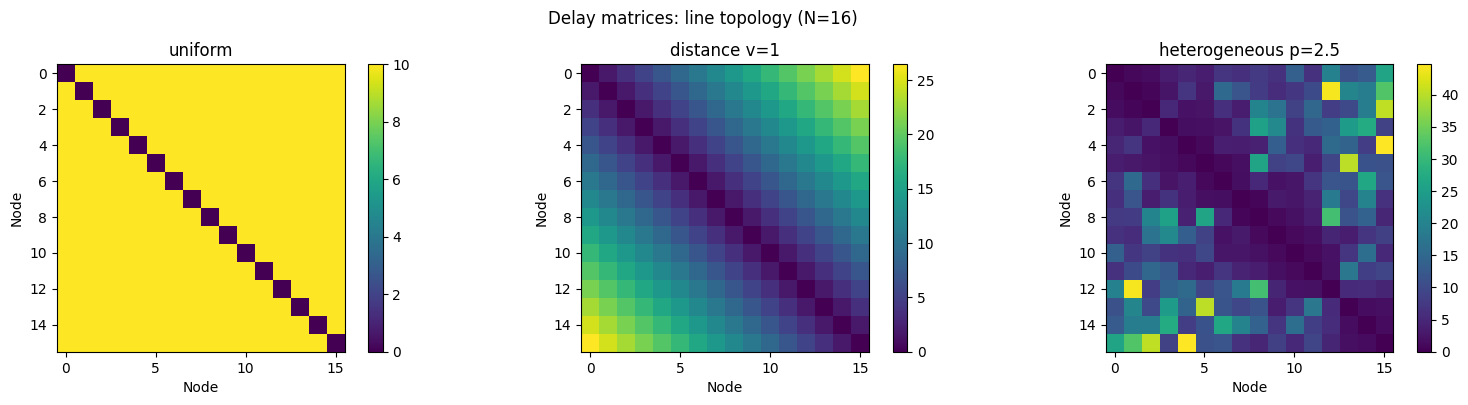

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Delay regime comparison: line topology (N=16)")

# Run all three regimes
configs = [
    ('uniform', dict(mode='uniform', rho=10.0)),
    ('distance v=1', dict(mode='distance', v=1, target_mean_rho=10.0)),
    ('heterogeneous p=2.5', dict(mode='heterogeneous', vm=6.0, p=2.5, target_mean_rho=10.0, seed=42))
]

for i, (label, kwargs) in enumerate(configs):
    m = Metapopulation()
    m.load_config(CONFIG)
    m.create_network(params={'topology': 'line'})
    m.create_delay_matrix(**kwargs)
    m.initialise_model()
    m.run_simulation()
    
    t = m.model.time_array
    mask = t >= 20 # & (t < 80)
    traj = m.model.trajectories
    
    axes[i].plot(t[mask], traj[0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
    axes[i].plot(t[mask], traj[1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
    axes[i].set_title(label)
    axes[i].set_ylim(0, 1)
    axes[i].set_xlabel("Time (ms)")
    if i == 0:
        axes[i].set_ylabel("Activity")

plt.tight_layout()
plt.savefig("regime_comparison_line.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Delay matrices: line topology (N=16)")

m_temp = Metapopulation()
m_temp.load_config(CONFIG)
m_temp.create_network(params={'topology': 'line'})

D_uniform = uniform_delay_matrix(m_temp.network, rho=10.0)
D_distance = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
D_hetero = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=2.5, target_mean_rho=10.0, seed=42)

matrices = [D_uniform, D_distance, D_hetero]
labels = ['uniform', 'distance v=1', 'heterogeneous p=2.5']

for i, (D, label) in enumerate(zip(matrices, labels)):
    im = axes[i].imshow(D, cmap='viridis')
    axes[i].set_title(label)
    axes[i].set_xlabel("Node")
    axes[i].set_ylabel("Node")
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.savefig("kavya_figures/comparison_matrices_line.png", dpi=800)
plt.show()

Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10.,
        10., 10., 10.],
   

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10.,  0., 10., 10.,

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  5.40254285,  4.12137659,  6.05834803,  6.67580704,
         3.82756649,  6.31247131,  4.88005786,  5.18852283,  3.82962224,
         7.50333782,  3.17041754,  8.96333982,  4.6908348 ,  5.04803004,
         9.55389861],
       [ 5.40254285,  0.        ,  4.46070527,  7.13835629, 12.26868707,
         4.13864869, 16.6368619 , 10.77374123,  6.10318677,  3.84489967,
         4.29743439,  5.45645155, 21.94196442,  9.25295454,  8.00489846,
        12.70240575],
       [ 4.12137659,  4.46070527,  0.        , 27.8397392 ,  5.92081506,
         4.21669311,  8.44727929,  3.87439825, 18.35353213, 13.29582582,
         6.00037874,  8.95609329,  4.43524245,  4.9123802 ,  8.53719253,
        17.0217819 ],
       [ 6.05834803,  7.13835629, 27.8397392 ,  0.        ,  9.24613119,
         4.84058719,  4.33185056,  8.92950

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.


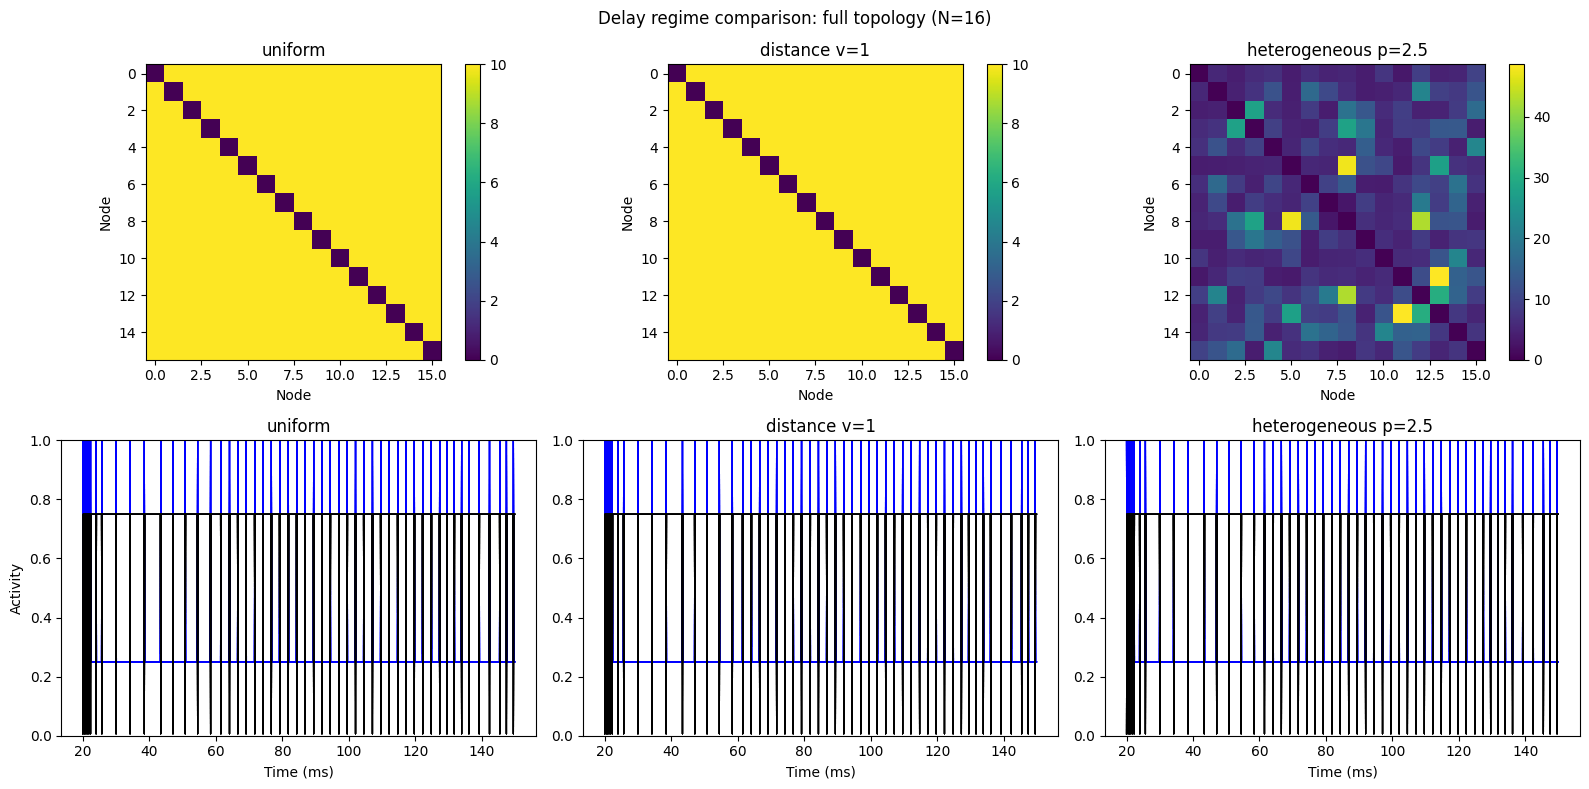

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Delay regime comparison: full topology (N=16)")

m_temp = Metapopulation()
m_temp.load_config(CONFIG)
m_temp.create_network(params={'topology': 'full'})

D_uniform = uniform_delay_matrix(m_temp.network, rho=10.0)
D_distance = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
D_hetero = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=2.5, target_mean_rho=10.0, seed=42)

matrices = [D_uniform, D_distance, D_hetero]
labels = ['uniform', 'distance v=1', 'heterogeneous p=2.5']

for i, (D, label) in enumerate(zip(matrices, labels)):
    im = axes[0, i].imshow(D, cmap='viridis')
    axes[0, i].set_title(label)
    axes[0, i].set_xlabel("Node")
    axes[0, i].set_ylabel("Node")
    plt.colorbar(im, ax=axes[0, i])

configs = [
    ('uniform', dict(mode='uniform', rho=10.0)),
    ('distance v=1', dict(mode='distance', v=1, target_mean_rho=10.0)),
    ('heterogeneous p=2.5', dict(mode='heterogeneous', vm=6.0, p=2.5, target_mean_rho=10.0, seed=42))
]

for i, (label, kwargs) in enumerate(configs):
    m = Metapopulation()
    m.load_config(CONFIG)
    m.create_network(params={'topology': 'full'})
    m.create_delay_matrix(**kwargs)
    m.initialise_model()
    m.run_simulation()
    
    t = m.model.time_array
    mask = (t >= 20) #& (t < 80)
    traj = m.model.trajectories
    
    axes[1, i].plot(t[mask], traj[0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
    axes[1, i].plot(t[mask], traj[1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
    axes[1, i].set_title(label)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_xlabel("Time (ms)")
    if i == 0:
        axes[1, i].set_ylabel("Activity")

plt.tight_layout()
plt.savefig("kavya_figures/comparison_full.png", dpi=800)
plt.show()

Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10.,
        10., 10., 10.],
   

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  5.55555556,  5.55555556,  5.55555556, 11.11111111,
        11.11111111, 11.11111111, 16.66666667, 16.66666667, 16.66666667,
        11.11111111, 11.11111111, 11.11111111,  5.55555556,  5.55555556,
         5.55555556],
       [ 5.55555556,  0.        ,  5.55555556,  5.55555556,  5.55555556,
        11.11111111, 11.11111111, 11.11111111, 16.66666667, 16.66666667,
        16.66666667, 11.11111111, 11.11111111, 11.11111111,  5.55555556,
         5.55555556],
       [ 5.55555556,  5.55555556,  0.        ,  5.55555556,  5.55555556,
         5.55555556, 11.11111111, 11.11111111, 11.11111111, 16.66666667,
        16.66666667, 16.66666667, 11.11111111, 11.11111111, 11.11111111,
         5.55555556],
       [ 5.55555556,  5.55555556,  5.55555556,  0.        ,  5.55555556,
         5.55555556,  5.55555556, 11.11111

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  3.0671226 ,  2.33978103,  3.43943522,  7.57995604,
         4.34595931,  7.16741134,  8.31149489,  8.83685853,  6.52244022,
         8.51956482,  3.5998083 , 10.17730462,  2.6630729 ,  2.86585918,
         5.42392336],
       [ 3.0671226 ,  0.        ,  2.53242415,  4.05257571,  6.96515853,
         4.69917345, 18.89010288, 12.23290074, 10.39467299,  6.54846006,
         7.31919682,  6.19545512, 24.91371077, 10.50614378,  4.54452758,
         7.21138857],
       [ 2.33978103,  2.53242415,  0.        , 15.80513023,  3.36135524,
         2.39389397,  9.59135057,  4.39913381, 20.83927319, 22.64485206,
        10.21957498, 15.25361497,  5.03593686,  5.57769656,  9.69344137,
         9.66357759],
       [ 3.43943522,  4.05257571, 15.80513023,  0.        ,  5.24919815,
         2.74809007,  2.45927097, 10.13889

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.


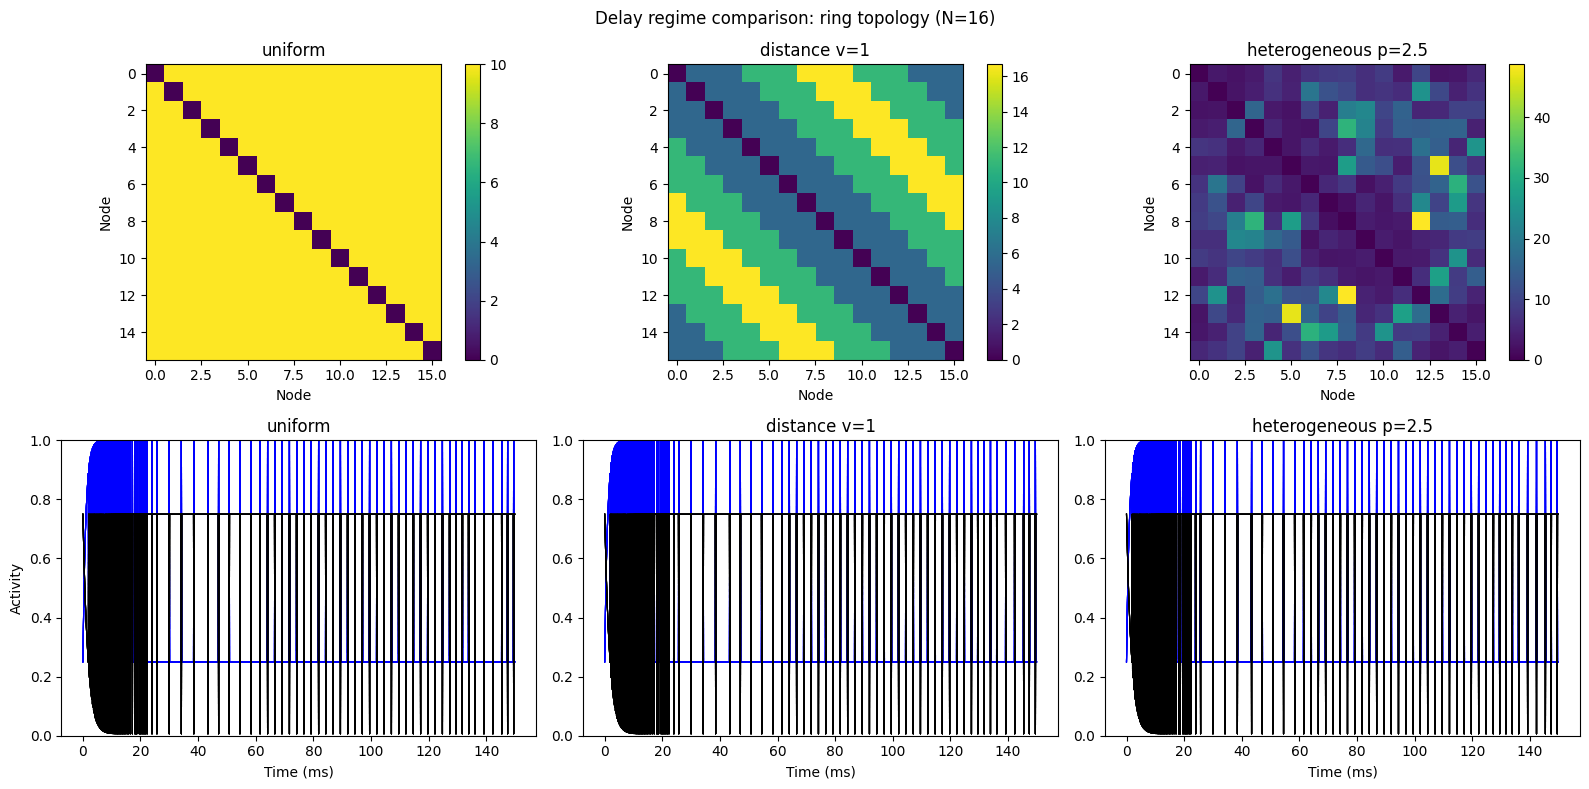

In [80]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Delay regime comparison: ring topology (N=16)")

m_temp = Metapopulation()
m_temp.load_config(CONFIG)
m_temp.create_network(params={'topology': 'ring'})

D_uniform = uniform_delay_matrix(m_temp.network, rho=10.0)
D_distance = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
D_hetero = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=2.5, target_mean_rho=10.0, seed=42)

matrices = [D_uniform, D_distance, D_hetero]
labels = ['uniform', 'distance v=1', 'heterogeneous p=2.5']

for i, (D, label) in enumerate(zip(matrices, labels)):
    im = axes[0, i].imshow(D, cmap='viridis')
    axes[0, i].set_title(label)
    axes[0, i].set_xlabel("Node")
    axes[0, i].set_ylabel("Node")
    plt.colorbar(im, ax=axes[0, i])

configs = [
    ('uniform', dict(mode='uniform', rho=10.0)),
    ('distance v=1', dict(mode='distance', v=1, target_mean_rho=10.0)),
    ('heterogeneous p=2.5', dict(mode='heterogeneous', vm=6.0, p=2.5, target_mean_rho=10.0, seed=42))
]

for i, (label, kwargs) in enumerate(configs):
    m = Metapopulation()
    m.load_config(CONFIG)
    m.create_network(params={'topology': 'ring'})
    m.create_delay_matrix(**kwargs)
    m.initialise_model()
    m.run_simulation()
    
    t = m.model.time_array
    mask = t >= 20 & (t < 80)
    traj = m.model.trajectories
    
    axes[1, i].plot(t[mask], traj[0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
    axes[1, i].plot(t[mask], traj[1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
    axes[1, i].set_title(label)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_xlabel("Time (ms)")
    if i == 0:
        axes[1, i].set_ylabel("Activity")

plt.tight_layout()
plt.savefig("kavya_figures/comparison_ring.png", dpi=800)
plt.show()

Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10.,
        10., 10., 10.],
   

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.  ,  3.75,  7.5 , 11.25,  3.75,  7.5 , 11.25, 15.  ,  7.5 ,
        11.25, 15.  , 18.75, 11.25, 15.  , 18.75, 22.5 ],
       [ 3.75,  0.  ,  3.75,  7.5 ,  7.5 ,  3.75,  7.5 , 11.25, 11.25,
         7.5 , 11.25, 15.  , 15.  , 11.25, 15.  , 18.75],
       [ 7.5 ,  3.75,  0.  ,  3.75, 11.25,  7.5 ,  3.75,  7.5 , 15.  ,
        11.25,  7.5 , 11.25, 18.75, 15.  , 11.25, 15.  ],
       [11.25,  7.5 ,  3.75,  0.  , 15.  , 11.25,  7.5 ,  3.75, 18.75,
        15.  , 11.25,  7.5 , 22.5 , 18.75, 15.  , 11.25],
       [ 3.75,  7.5 , 11.25, 15.  ,  0.  ,  3.75,  7.5 , 11.25,  3.75,
         7.5 , 11.25, 15.  ,  7.5 , 11.25, 15.  , 18.75],
       [ 7.5 ,  3.75,  7.5 , 11.25,  3.75,  0.  ,  3.75,  7.5 ,  7.5 ,
         3.75,  7.5 , 11.25, 11.25,  7.5 , 11.25, 15.  ],
       [11.25,  7.5 ,  3.75,  7.5 ,  7.5 ,  3.75,  0.  ,  3.75, 

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  2.02436337,  3.08860624,  6.81029182,  2.50146266,
         2.86842163,  7.09595612,  7.31434114,  3.8883377 ,  4.30494334,
        11.24617249,  5.93986693, 10.07584239,  7.03072933,  9.45762704,
        21.47939909],
       [ 2.02436337,  0.        ,  1.6714515 ,  5.34956496,  9.19429288,
         1.55077508, 12.46785251, 12.11094533,  6.86069581,  2.88141131,
         4.83081892,  8.17825304, 32.88711271, 10.40140321, 11.99792292,
        23.79831641],
       [ 3.08860624,  1.6714515 ,  0.        , 10.43170775,  6.65568868,
         3.16003751,  3.16524333,  2.90351788, 27.5086892 , 14.94606341,
         4.49675171, 10.06769644,  8.30955216,  7.36278658,  9.59680299,
        25.51263183],
       [ 6.81029182,  5.34956496, 10.43170775,  0.        , 13.85831062,
         5.4413862 ,  3.24633782,  3.34593

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.


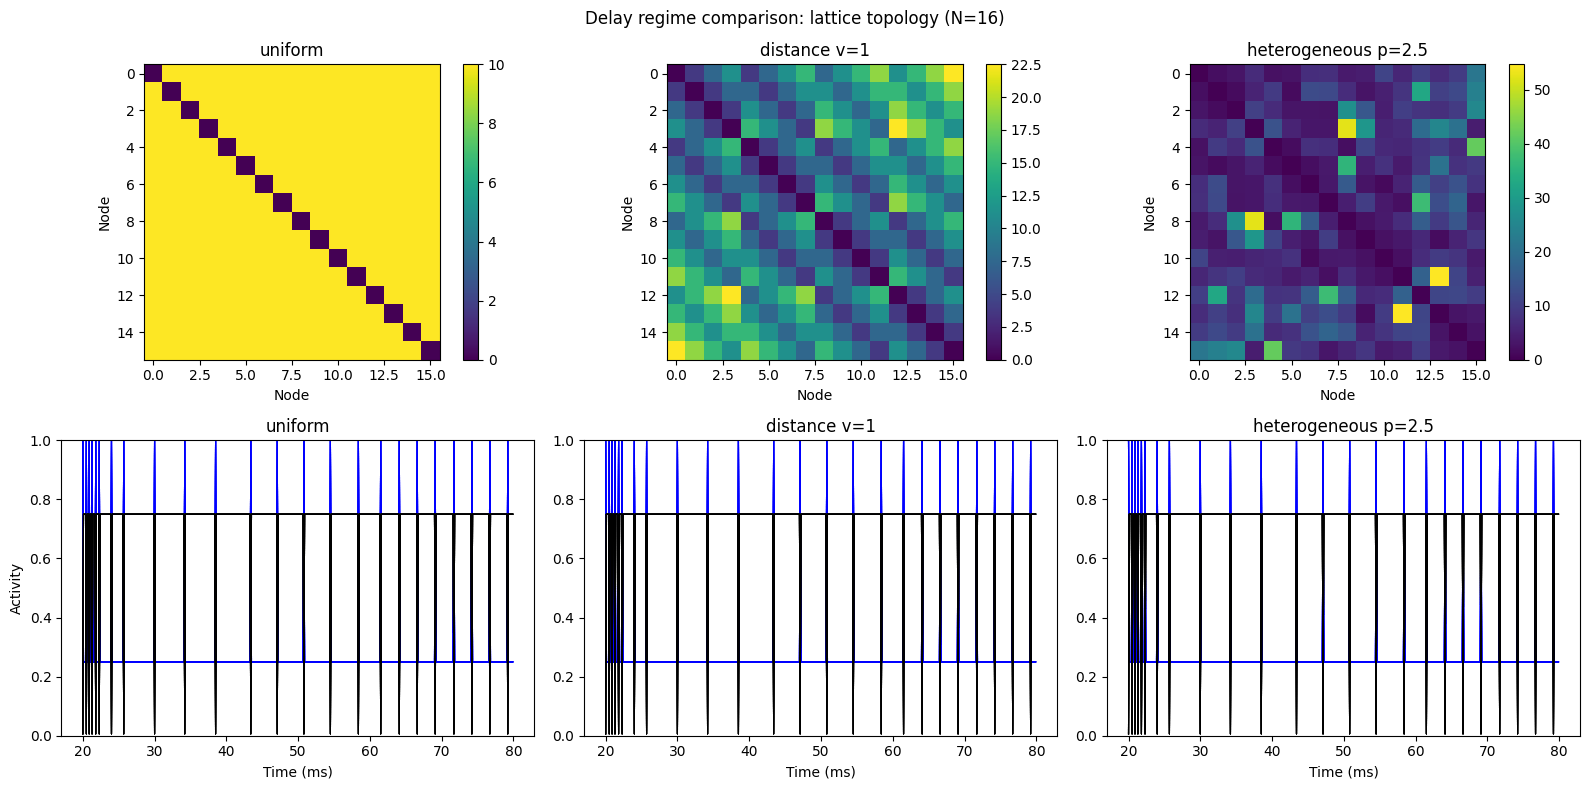

In [81]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Delay regime comparison: lattice topology (N=16)")

m_temp = Metapopulation()
m_temp.load_config(CONFIG)
m_temp.create_network(params={'topology': 'lattice'})

D_uniform = uniform_delay_matrix(m_temp.network, rho=10.0)
D_distance = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
D_hetero = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=2.5, target_mean_rho=10.0, seed=42)

matrices = [D_uniform, D_distance, D_hetero]
labels = ['uniform', 'distance v=1', 'heterogeneous p=2.5']

for i, (D, label) in enumerate(zip(matrices, labels)):
    im = axes[0, i].imshow(D, cmap='viridis')
    axes[0, i].set_title(label)
    axes[0, i].set_xlabel("Node")
    axes[0, i].set_ylabel("Node")
    plt.colorbar(im, ax=axes[0, i])

configs = [
    ('uniform', dict(mode='uniform', rho=10.0)),
    ('distance v=1', dict(mode='distance', v=1, target_mean_rho=10.0)),
    ('heterogeneous p=2.5', dict(mode='heterogeneous', vm=6.0, p=2.5, target_mean_rho=10.0, seed=42))
]

for i, (label, kwargs) in enumerate(configs):
    m = Metapopulation()
    m.load_config(CONFIG)
    m.create_network(params={'topology': 'lattice'})
    m.create_delay_matrix(**kwargs)
    m.initialise_model()
    m.run_simulation()
    
    t = m.model.time_array
    mask = (t >= 20) & (t < 80)
    traj = m.model.trajectories
    
    axes[1, i].plot(t[mask], traj[0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
    axes[1, i].plot(t[mask], traj[1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
    axes[1, i].set_title(label)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_xlabel("Time (ms)")
    if i == 0:
        axes[1, i].set_ylabel("Activity")

plt.tight_layout()
plt.savefig("kavya_figures/comparison_lattice.png", dpi=800)
plt.show()